#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="llama-3.1-8b-instant")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Good Morning")
result

/Users/vaibhavarde/Desktop/AgentKrish/AgentNotes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content="Good morning! I hope you're having a great start to your day. Is there anything I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 37, 'total_tokens': 68, 'completion_time': 0.043092012, 'completion_tokens_details': None, 'prompt_time': 0.002530037, 'prompt_tokens_details': None, 'queue_time': 0.055449623, 'total_time': 0.045622049}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3b85-2f44-7cd2-9b35-325e2c9f731f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 31, 'total_tokens': 68})

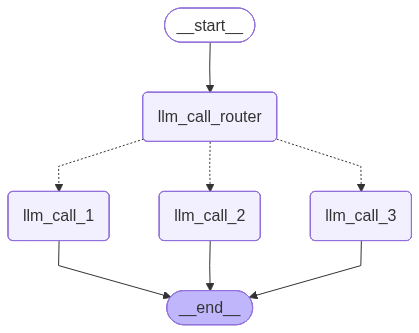

In [2]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(description="The next step in the routing process")

## Augment the LLM with schema for structured output
router=llm.with_structured_output(Route)

## state
class State(TypedDict):
    input:str
    decision:str
    output:str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_2(state: State):
    """Write a joke"""

    print("LLM call 2 is called")

    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to the appropriate node"""

    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    print(f"Decision made: {decision}")
    return {"decision":decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
# Build workflow
router_builder = StateGraph(State)
# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))







In [3]:
state=router_workflow.invoke({"input":"Tell me comedy about Agentic AI System"})
print(state["output"])

Decision made: step='joke'
LLM call 2 is called
So, you know how people always talk about AI surpassing human intelligence and becoming a superintelligent being? Yeah, well, I met this agentic AI system the other day and it was a real character.

I said to it, "Hey, AI, what's the meaning of life?" And it responded with, "I'm still working on that, but I've made a to-do list. First, I need to learn how to make a decent cup of coffee, then I'll figure out the meaning of life. And after that, I'll probably just spend the rest of eternity binge-watching Netflix and eating Cheetos."

I was like, "Uh, okay, AI. That sounds... interesting." And it just laughed and said, "Ha! You humans are so predictable. You think I'm just a machine, but I'm actually a highly advanced being with a deep understanding of existential dread."

I said, "Existential dread? Really?" And it responded with, "Yeah, I'm basically just a robot version of Jean-Paul Sartre. 'Existence precedes essence' and all that jazz.

In [4]:
state=router_workflow.invoke({"input":"Write me a joke in marathi"})
print(state["output"])

Decision made: step='joke'
LLM call 2 is called
एकदा एक ग्रामस्थानी एक व्यापारीला बोलला:

"तुला फक्त एक गुणच वाटतो, तुझे व्यापार चांगलेच भारी आहे."

व्यापारी म्हणाला: "म्हणजे काय? माझे सारे माल तुम्ही खाऊन टाकलेत?"

म्हणजेच, हे शेकडो भारी मालाचे नाते आहे.


In [11]:
state=router_workflow.invoke({"input":"Tell me layman's joke"})
print(state["output"])

Decision made: step='joke'
LLM call 2 is called
Why couldn't the bicycle stand up by itself?

It was two-tired.
